In [1]:
import gdown

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
import urllib.request
import zipfile

urllib.request.urlretrieve(url, "online_retail.zip")

with zipfile.ZipFile("online_retail.zip", "r") as z:
    z.extractall(".")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("Online Retail.xlsx")

In [6]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [7]:
df.sample()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
251522,559055,22233,JIGSAW RABBIT AND BIRDHOUSE,7,2011-07-05 17:09:00,1.25,NaN,United Kingdom


In [8]:
df.shape

(541909, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [12]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent.round(2)
})

In [13]:
# Check for negative quantities (returns/cancellations)
print("Negative Quantities:", (df['Quantity'] < 0).sum())

# Check for negative prices
print("Negative UnitPrice:", (df['UnitPrice'] < 0).sum())

# Check for zero prices
print("Zero UnitPrice:", (df['UnitPrice'] == 0).sum())

Negative Quantities: 10624
Negative UnitPrice: 2
Zero UnitPrice: 2515


In [15]:
duplicates = df.duplicated().sum()
print(duplicates)

5268


In [16]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Earliest date:", df['InvoiceDate'].min())
print("Latest date:", df['InvoiceDate'].max())
print("Date range:", (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days, "days")
#used to calculate recency

Earliest date: 2010-12-01 08:26:00
Latest date: 2011-12-09 12:50:00
Date range: 373 days


In [17]:
# top 10 countries
print("Unique countries:", df['Country'].nunique())
df['Country'].value_counts().head(10)

Unique countries: 38


,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


/tmp/ipykernel_485/1669702608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


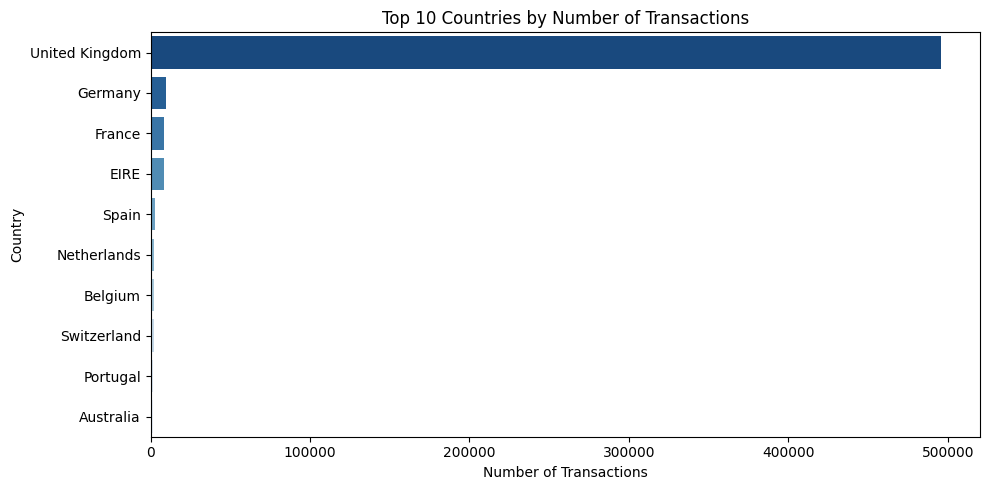

In [18]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [19]:
#data cleaning
print("Rows before removing missing CustomerID:", len(df))

df = df.dropna(subset=['CustomerID'])

print("Rows after removing missing CustomerID:", len(df))
print(f"Rows removed: {541909 - len(df)}")

Rows before removing missing CustomerID: 541909
Rows after removing missing CustomerID: 406829
Rows removed: 135080


In [20]:
print("Rows before removing cancellations:", len(df))

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]  # Remove cancellations
df = df[df['Quantity'] > 0]                                 # Remove negative quantities
df = df[df['UnitPrice'] > 0]                                # Remove zero/negative prices

print("Rows after removing cancellations:", len(df))

Rows before removing cancellations: 406829
Rows after removing cancellations: 397884


In [21]:
print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows before removing duplicates: 397884
Rows after removing duplicates: 392692


In [22]:
# Making sure these columns are the correct type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)  # Remove decimal from ID
print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


In [23]:
# Each row is one line item — quantity × unit price = total for that line
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [24]:
print("FINAL CLEAN DATASET")
print(f"Total rows: {len(df)}")
print(f"Total unique customers: {df['CustomerID'].nunique()}")
print(f"\nMissing values remaining:")
print(df.isnull().sum())
print(f"\nSample of clean data:")
df.head()

FINAL CLEAN DATASET
Total rows: 392692
Total unique customers: 4338

Missing values remaining:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

Sample of clean data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [25]:
df.shape

(392692, 9)

In [26]:

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)
#using the day after last transaction

Reference date: 2011-12-10 12:50:00


In [27]:
recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df.columns = ['CustomerID', 'LastPurchaseDate']
recency_df['Recency'] = (reference_date - recency_df['LastPurchaseDate']).dt.days
recency_df.head()
#the lower the recency the better the score

,CustomerID,LastPurchaseDate,Recency
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310


In [28]:

frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.columns = ['CustomerID', 'Frequency']
frequency_df.head()

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [29]:
monetary_df = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary_df.columns = ['CustomerID', 'Monetary']
monetary_df.head()
#higher value spent more money

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [30]:
rfm = recency_df[['CustomerID', 'Recency']].merge(frequency_df, on='CustomerID')
rfm = rfm.merge(monetary_df, on='CustomerID')
print(f"Total customers: {len(rfm)}")
rfm.head(10)
#rfm table

Total customers: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [31]:
print("RFM Summary Statistics")
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

RFM Summary Statistics


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


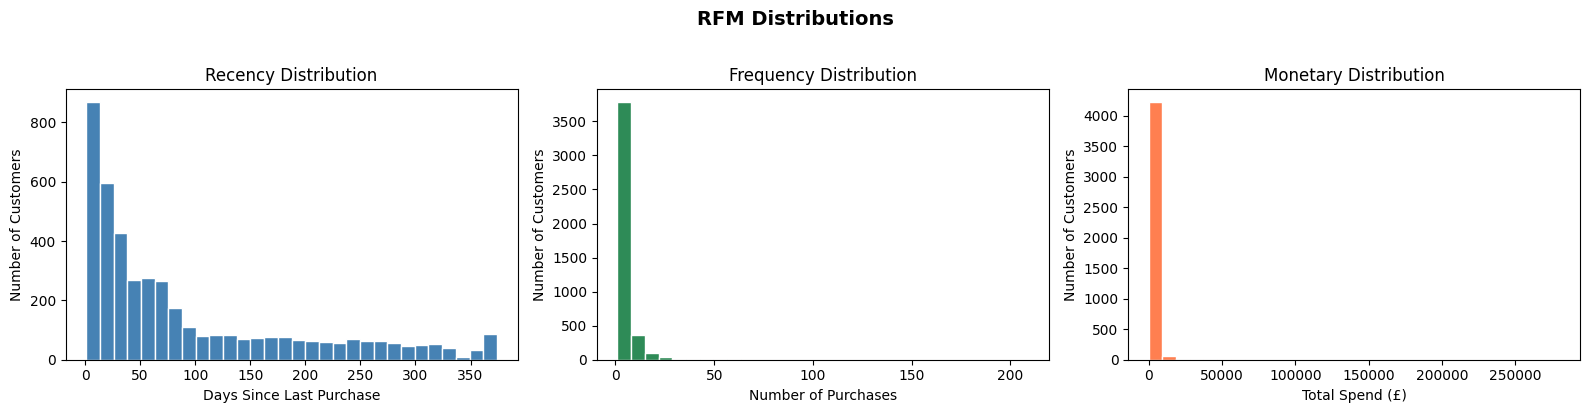

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Recency
axes[0].hist(rfm['Recency'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

# Frequency
axes[1].hist(rfm['Frequency'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')

# Monetary
axes[2].hist(rfm['Monetary'], bins=30, color='coral', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend (£)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('RFM Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [33]:
#scoring recency
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm[['CustomerID', 'Recency', 'R_Score']].head(10)

,CustomerID,Recency,R_Score
0,12346,326,1
1,12347,2,5
2,12348,75,2
3,12349,19,4
4,12350,310,1
5,12352,36,3
6,12353,204,1
7,12354,232,1
8,12355,214,1
9,12356,23,4


In [34]:
#scoring frequency
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm[['CustomerID', 'Frequency', 'F_Score']].head(10)

,CustomerID,Frequency,F_Score
0,12346,1,1
1,12347,7,5
2,12348,4,4
3,12349,1,1
4,12350,1,1
5,12352,8,5
6,12353,1,1
7,12354,1,1
8,12355,1,1
9,12356,3,3


In [35]:
#scoring monetary value
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm[['CustomerID', 'Monetary', 'M_Score']].head(10)

,CustomerID,Monetary,M_Score
0,12346,77183.60,5
1,12347,4310.00,5
2,12348,1797.24,4
3,12349,1757.55,4
4,12350,334.40,2
5,12352,2506.04,5
6,12353,89.00,1
7,12354,1079.40,4
8,12355,459.40,2
9,12356,2811.43,5


In [36]:
#combined rfm score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
# a numeric total score (3 = worst, 15 = best)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total']].head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,2506.04,3,5,5,355,13
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,1079.40,1,1,4,114,6
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,2811.43,4,3,5,435,12


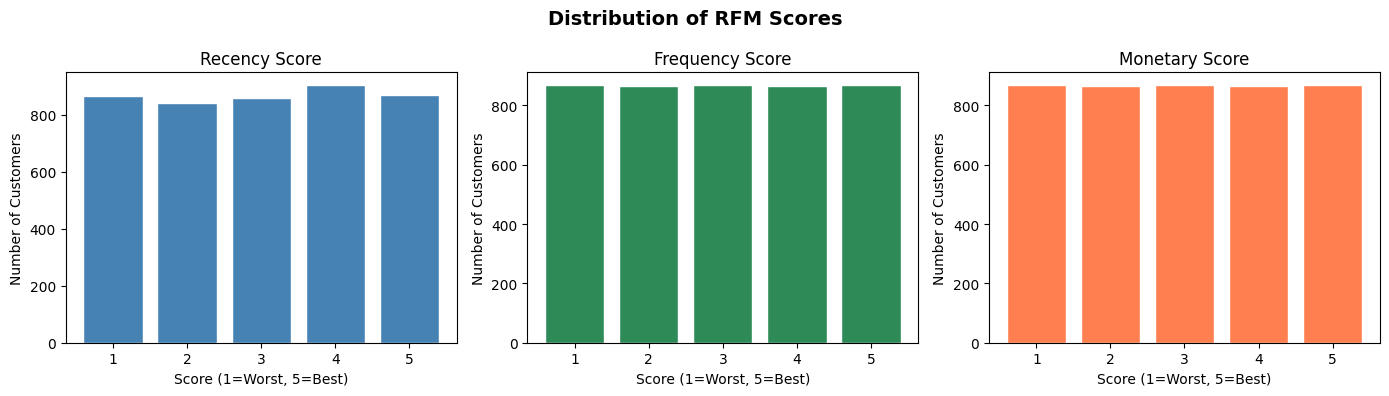

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color, title in zip(
    axes,
    ['R_Score', 'F_Score', 'M_Score'],
    ['steelblue', 'seagreen', 'coral'],
    ['Recency Score', 'Frequency Score', 'Monetary Score']
):
    score_counts = rfm[col].value_counts().sort_index()
    ax.bar(score_counts.index, score_counts.values, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Score (1=Worst, 5=Best)')
    ax.set_ylabel('Number of Customers')
    ax.set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Distribution of RFM Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
print("Final Scored RFM Table")
print(f"Total customers scored: {len(rfm)}")
rfm.head(10)

Final Scored RFM Table
Total customers scored: 4338


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,2506.04,3,5,5,355,13
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,1079.40,1,1,4,114,6
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,2811.43,4,3,5,435,12


In [42]:
#segmentation rules
def segment_customer(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Promising'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

,count
Segment,
Needs Attention,1130
Champions,957
Loyal Customers,764
At Risk,453
Lost,364
Potential Loyalists,351
Promising,319


In [43]:
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_RFM_Total=('RFM_Total', 'mean')
).round(2).sort_values('Avg_RFM_Total', ascending=False)

print("Segment Summary")
segment_summary

Segment Summary


,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_RFM_Total
Segment,,,,,
Champions,957,12.82,11.12,6051.87,13.92
Loyal Customers,764,35.69,4.12,1827.90,11.08
At Risk,453,141.61,3.81,1632.40,9.17
Promising,319,18.52,1.24,455.23,7.84
Potential Loyalists,351,53.50,1.16,459.00,6.56
Needs Attention,1130,151.86,1.64,403.05,6.21
Lost,364,278.68,1.00,543.42,3.71


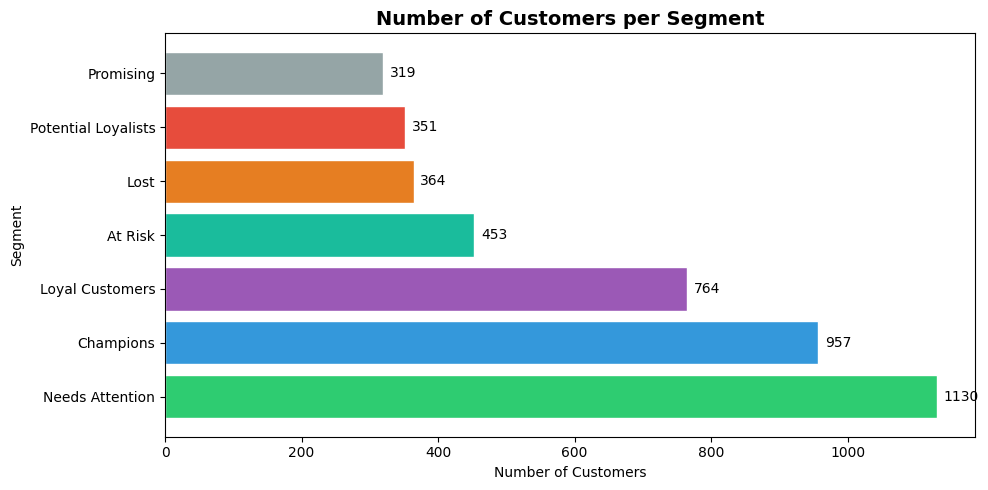

In [44]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))
colors = ['#2ecc71','#3498db','#9b59b6','#1abc9c','#e67e22','#e74c3c','#95a5a6','#f39c12']
bars = plt.barh(segment_counts.index, segment_counts.values, color=colors, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)

plt.title('Number of Customers per Segment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

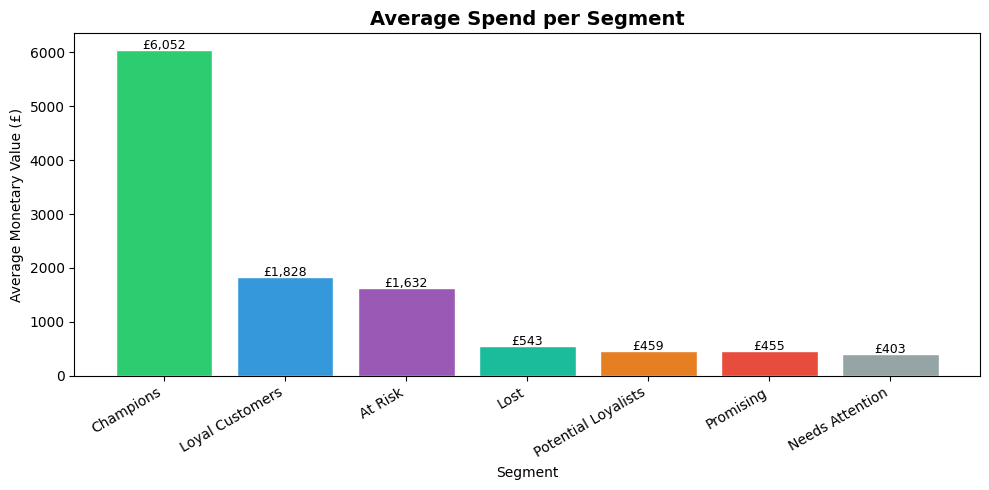

In [45]:
#average monetary value
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71','#3498db','#9b59b6','#1abc9c','#e67e22','#e74c3c','#95a5a6','#f39c12']
bars = plt.bar(seg_monetary.index, seg_monetary.values, color=colors, edgecolor='white')

for bar, val in zip(bars, seg_monetary.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'£{val:,.0f}', ha='center', fontsize=9)

plt.title('Average Spend per Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Average Monetary Value (£)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

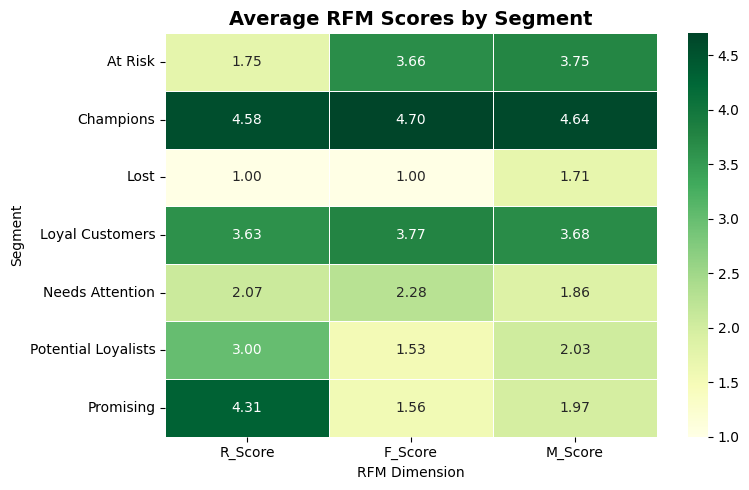

In [46]:
# Heatmap per segment
heatmap_data = rfm.groupby('Segment')[['R_Score','F_Score','M_Score']].mean().round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, linecolor='white')
plt.title('Average RFM Scores by Segment', fontsize=14, fontweight='bold')
plt.ylabel('Segment')
plt.xlabel('RFM Dimension')
plt.tight_layout()
plt.show()

In [47]:
# interprations and insights
interpretations = {
    'Champions':          'Best customers. Bought recently, buy often, spend the most. Reward them.',
    'Loyal Customers':    'Buy regularly and spend well. encourage them to buy more expensive items.',
    'Promising':          'Recent buyers but not frequent yet. Nurture them with welcome offers.',
    'Potential Loyalists':'Show some loyalty. Offer membership or loyalty programs to convert them.',
    'At Risk':            'Were good customers but fading. Send win-back campaigns.',
    'Cannot Lose Them':   'Used to be top customers. Re-engage immediately with special offers.',
    'Needs Attention':    'Average customers going quiet. Offer limited-time promotions to re-activate.',
    'Lost':               'Lowest scores across all dimensions. Low priority — minimal re-engagement effort.'
}

interp_df = pd.DataFrame(list(interpretations.items()),
                          columns=['Segment', 'Business Interpretation'])
interp_df

,Segment,Business Interpretation
0,Champions,"Best customers. Bought recently, buy often, sp..."
1,Loyal Customers,Buy regularly and spend well. encourage them t...
2,Promising,Recent buyers but not frequent yet. Nurture th...
3,Potential Loyalists,Show some loyalty. Offer membership or loyalty...
4,At Risk,Were good customers but fading. Send win-back ...
5,Cannot Lose Them,Used to be top customers. Re-engage immediatel...
6,Needs Attention,Average customers going quiet. Offer limited-t...
7,Lost,Lowest scores across all dimensions. Low prior...
